## DBSCAN Clustering

### DBSCAN

**DBSCAN** stands for:

> **Density-Based Spatial Clustering of Applications with Noise**

It is a **density-based** clustering algorithm.

Unlike K-Means, DBSCAN focuses on how **closely packed** the samples are.

---

## 1. Two Main Parameters

DBSCAN mainly uses two parameters:

### $\epsilon$ (Epsilon)

$\epsilon$ defines the **neighborhood radius** around a sample.

In simple words:

> Look inside a circle of radius $\epsilon$ around the sample.

All samples inside this $\epsilon$-neighborhood are considered nearby points.

### `min_samples`

`min_samples` tells us the **minimum number of samples required inside the $\epsilon$-neighborhood** for the density requirement to be satisfied.

For example:

$$
\text{min\_samples}=5
$$

means the neighborhood needs at least **5 samples** to satisfy the density requirement.



---

## 2. Three Types of Samples

DBSCAN classifies samples into **three categories**:

1. **Core Point**
2. **Border Point**
3. **Noise / Outlier**

---

## 1. Core Point

A point is a **core point** when its $\epsilon$-neighborhood contains at least `min_samples` samples.

For example:

$$
\text{min\_samples}=5
$$

If the $\epsilon$-neighborhood contains enough samples to satisfy this requirement, the point is a **core point**.

**Easy idea:**

> Enough nearby points → **Core Point**

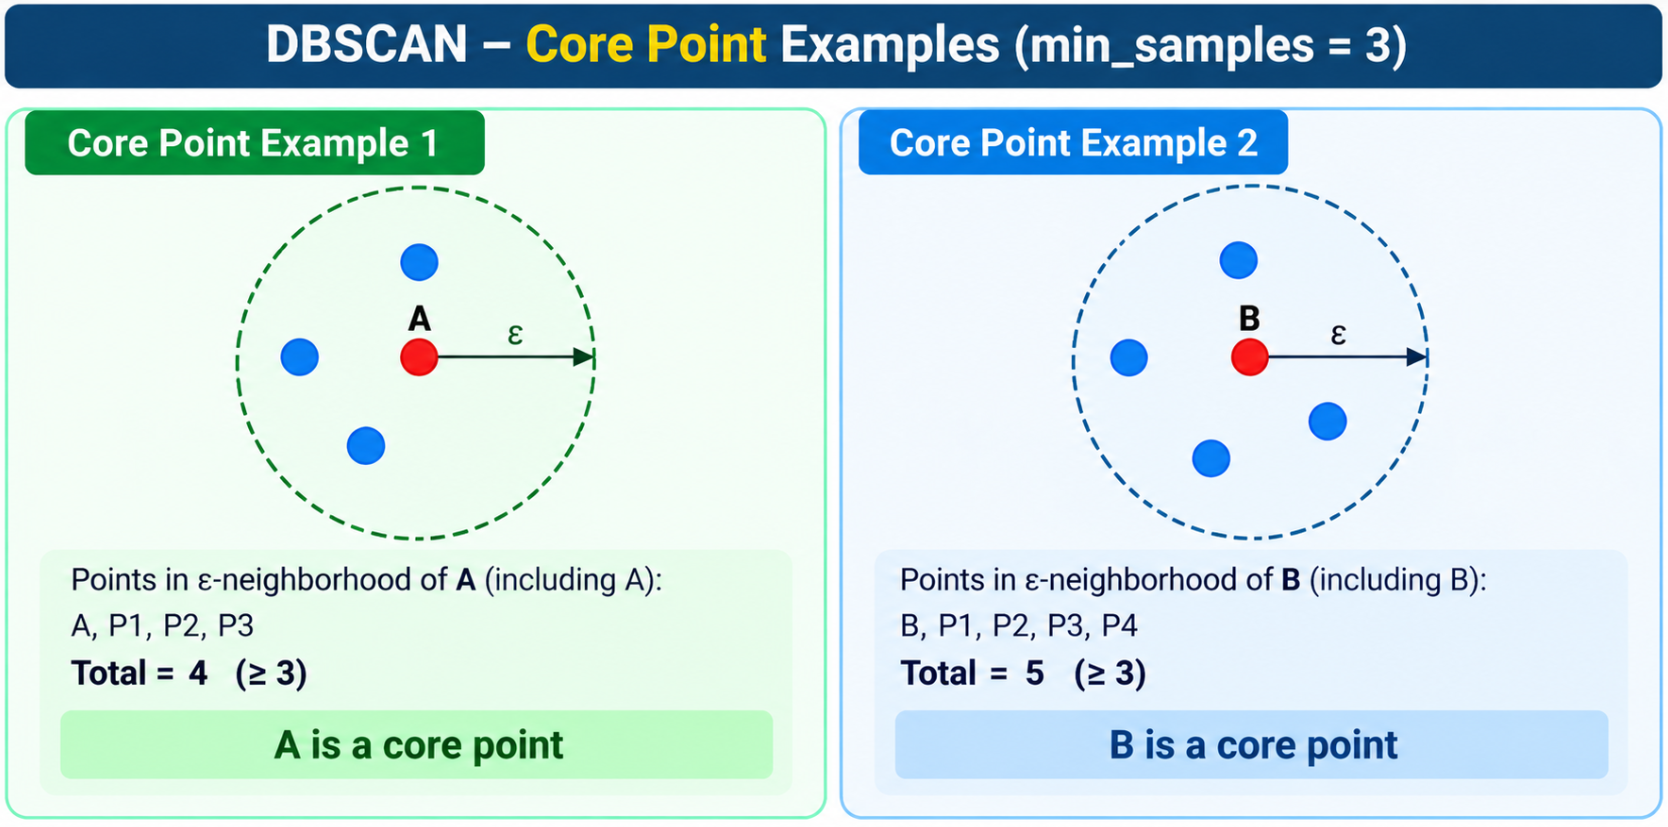

---

## 2. Border Point

A **border point** does not have enough samples in its own $\epsilon$-neighborhood to satisfy `min_samples`.

However, it lies within the $\epsilon$-neighborhood of a **core point**.

**Easy idea:**

> Not dense enough itself, but close to a core point → **Border Point**

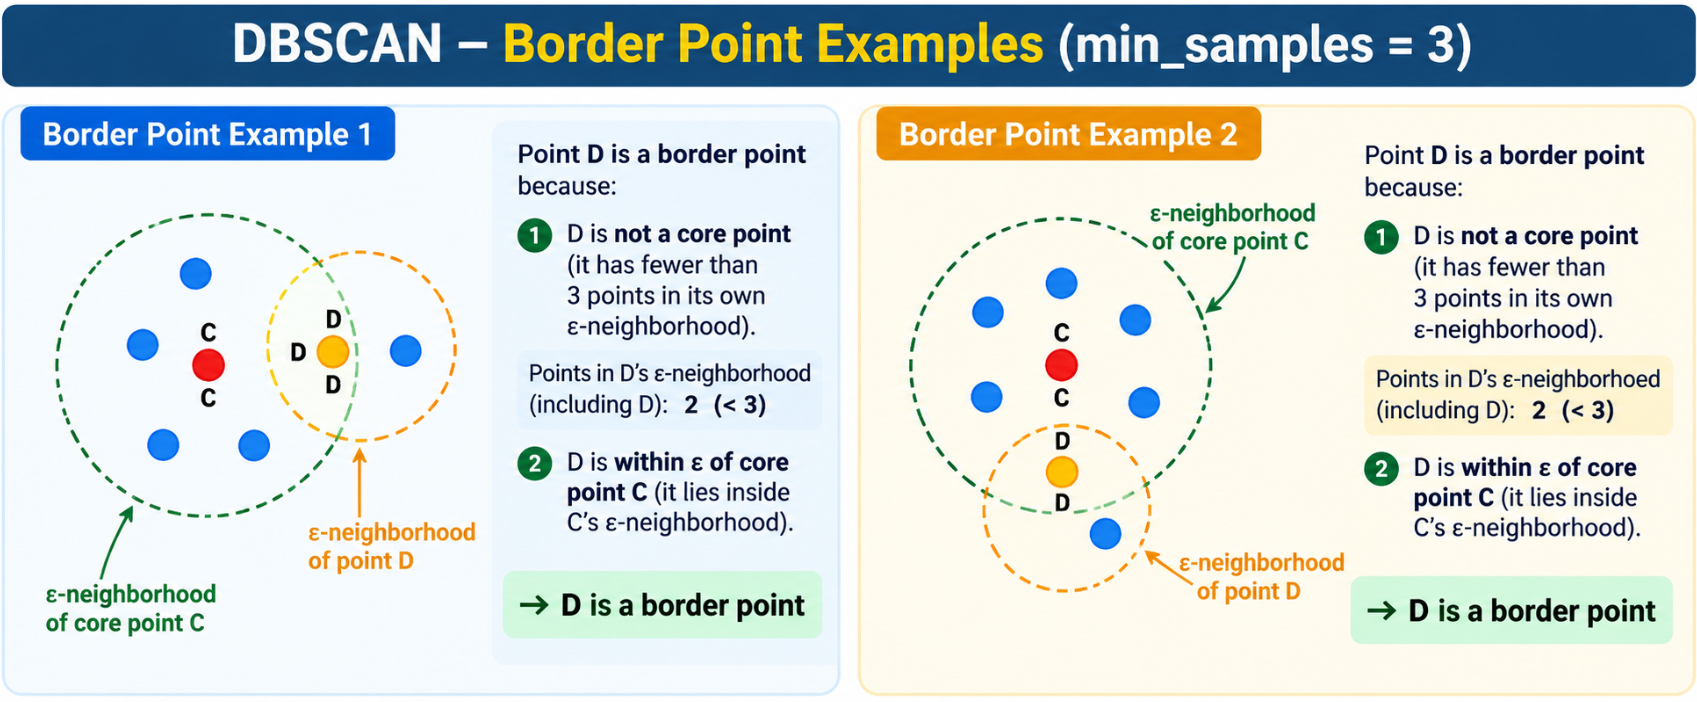

---

## 3. Noise / Outlier

A point is **noise (outlier)** when it does not satisfy the core-point condition and is not reachable from a core point.

**Easy idea:**

> Not dense + not connected to a core point → **Noise**

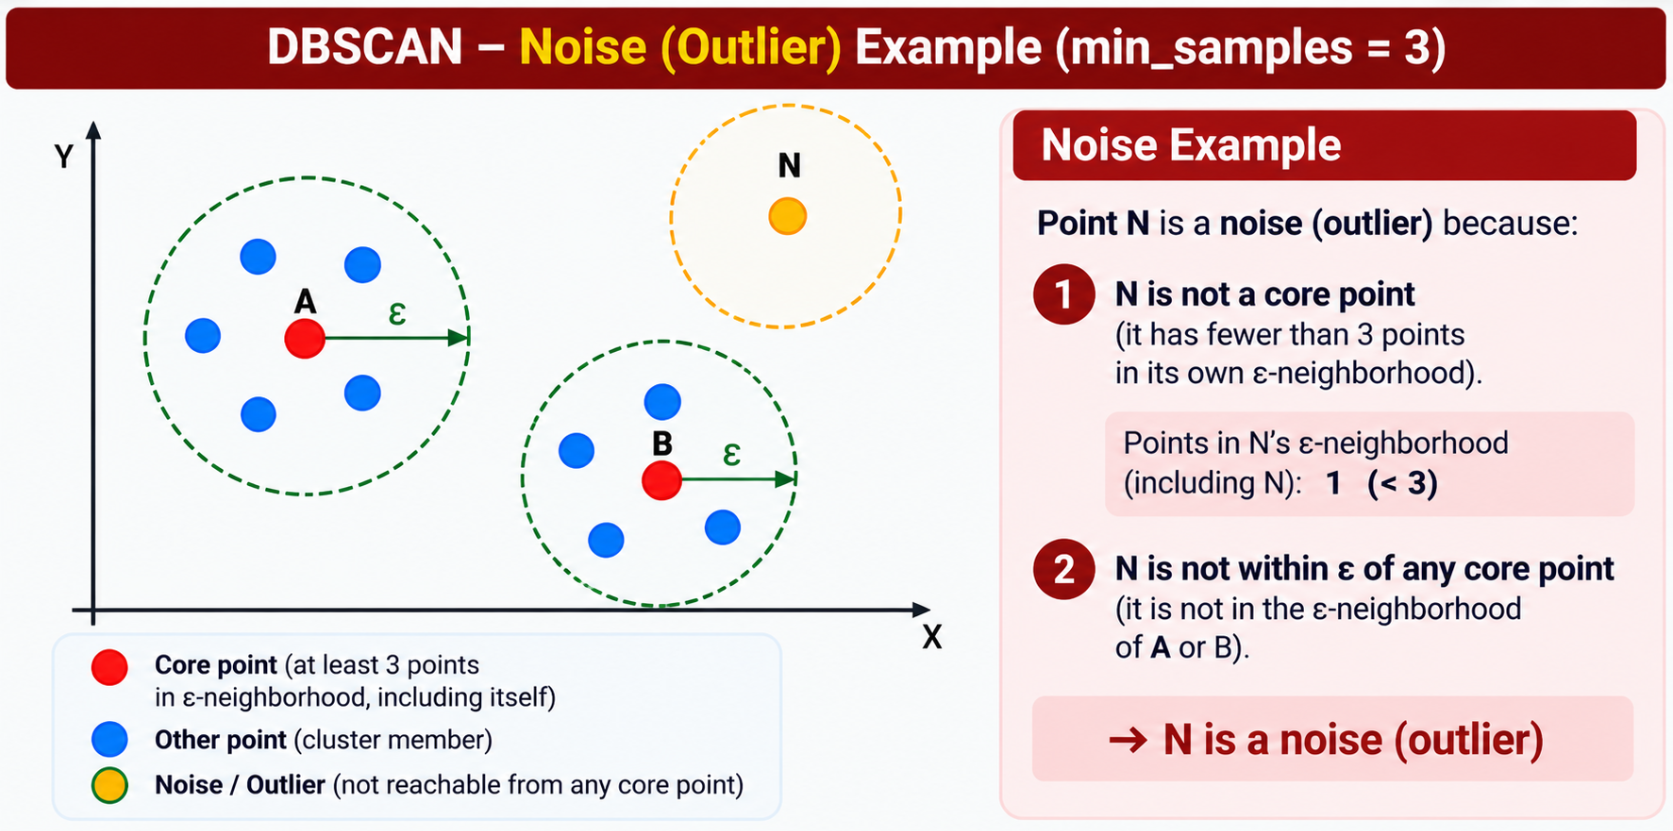

---

## 3. How DBSCAN Builds Clusters



### Step 1: Pick an unvisited sample

Choose one sample that has not been processed yet.

### Step 2: Check whether it is a Core Point

Look at its $\epsilon$-neighborhood and count the samples inside it.

If:

$$
\text{number of samples in neighborhood}
\geq
\text{min\_samples}
$$

then it is a **core point**.

### Step 3: Build the Cluster

If the selected point is a core point:

- start a new cluster
- add its nearby points
- check the newly added points
- if another point is also a core point, expand the cluster from that point too

So the cluster keeps growing through the connected dense region.

### Step 4: Check the Next Unvisited Sample

After finishing the current cluster, choose another unvisited sample.

Again:

$$
\text{Check neighborhood}
\rightarrow
\text{Check density}
\rightarrow
\text{Expand if core}
$$

Continue until all samples have been processed.

---

## 4. Simple Example

Suppose:

$$
\text{min\_samples}=3
$$

For a point, its $\epsilon$-neighborhood contains enough nearby samples.

Therefore:

$$
\text{Core Point}
$$

Its nearby points can become part of the same cluster.

If another nearby point is also a core point, we expand the cluster from that point as well.

This is how a dense region grows into a complete cluster.

---

## 5. Noise / Outlier

Consider a sample far away from the dense regions.

Its $\epsilon$-neighborhood does not contain enough samples.

It also does not lie within the neighborhood of a core point.

Therefore, it is classified as:

$$
\boxed{\text{Noise / Outlier}}
$$

This is an important feature of DBSCAN: **it can explicitly identify outliers.**

---

## 6. DBSCAN Process — Easy Flow

$$
\boxed{\text{Pick unvisited sample}}
$$

↓

$$
\boxed{\text{Check its }\epsilon\text{-neighborhood}}
$$

↓

$$
\boxed{\text{Enough samples?}}
$$

↓

**Yes → Core Point → Start/expand cluster**

**No → Check whether it is connected to a core point**

↓

**Connected → Border Point**

**Not connected → Noise / Outlier**

↓

**Pick the next unvisited sample and repeat**

---

## 7. Easy Memory Trick

### $\epsilon$

**How far do I look?**

### `min_samples`

**How many samples do I need nearby?**

### Core

**Enough neighbors**

### Border

**Not enough itself, but near a core**

### Noise

**Not dense and not connected to a core**

---

## One-line Summary

> **DBSCAN finds dense regions using $\epsilon$ and `min_samples`, grows clusters from core points, includes border points, and labels isolated points as noise.**
